In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
from pathlib import Path

# Scikit-Learn & XGBoost
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, classification_report

# Setup paths dynamically
sys.path.append(str(Path.cwd().parent))
import src.config as config

# Create required output directories
MODELS_DIR = config.PROJECT_ROOT / "models"
RESULTS_DIR = config.PROJECT_ROOT / "results"
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
FEATURES_DIR = config.PROJECT_ROOT / "features"

sns.set_theme(style="whitegrid")
print("Libraries imported and directories ready!")

2026-04-09 15:12:44 - src.config - INFO - Project configuration loaded and directories verified.


Libraries imported and directories ready!


In [ ]:
checkpoints = [4, 8, 12]
results_data = []

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define our baseline and advanced models with hyperparameter grids
models = {
    'LogisticRegression': {
        'estimator': LogisticRegression(random_state=42, max_iter=1000),
        'params': {'C': [0.1, 1, 10]}
    },
    'DecisionTree': {
        'estimator': DecisionTreeClassifier(random_state=42),
        'params': {'max_depth': [3, 5, 10], 'min_samples_leaf': [2, 5]}
    },
    'RandomForest': {
        'estimator': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
        'params': {'max_depth': [5, 10, None], 'min_samples_leaf': [2, 5]}
    },
    'XGBoost': {
        # scale_pos_weight is kept at 1 because SMOTE already balanced our training data
        'estimator': XGBClassifier(scale_pos_weight=1, random_state=42, eval_metric='logloss'),
        'params': {'learning_rate': [0.01, 0.1], 'n_estimators': [100, 200], 'max_depth': [3, 5]}
    }
}

for cp in checkpoints:
    print(f"\n{'='*30}\nTraining Models for Checkpoint {cp}\n{'='*30}")
    
    # Load the processed data from Phase 4
    train_df = pd.read_csv(FEATURES_DIR / f"checkpoint_{cp}_train.csv")
    val_df = pd.read_csv(FEATURES_DIR / f"checkpoint_{cp}_val.csv")
    
    X_train, y_train = train_df.drop(columns=['target']), train_df['target']
    X_val, y_val = val_df.drop(columns=['target']), val_df['target']
    
    for model_name, config_dict in models.items():
        print(f"Optimizing {model_name}...")
        
        # Grid Search optimizing for F1-Macro
        grid = GridSearchCV(
            config_dict['estimator'], 
            config_dict['params'], 
            cv=cv, 
            scoring='f1_macro', 
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        
        # Best model evaluation on Validation Set
        best_model = grid.best_estimator_
        y_val_pred = best_model.predict(X_val)
        val_f1 = f1_score(y_val, y_val_pred, average='macro')
        
        print(f"  Best Params: {grid.best_params_}")
        print(f"  Validation F1-Macro: {val_f1:.4f}")
        
        # Save results for Figure 1
        results_data.append({
            'Checkpoint': f"Week {cp}",
            'Model': model_name,
            'Val_F1_Macro': val_f1
        })
        
        # Save specific deliverable models (using Checkpoint 12 as the final saved state)
        if cp == 12:
            if model_name == 'LogisticRegression':
                joblib.dump(best_model, MODELS_DIR / "baseline_lr.joblib")
            elif model_name == 'RandomForest':
                joblib.dump(best_model, MODELS_DIR / "rf_model.joblib")
            elif model_name == 'XGBoost':
                joblib.dump(best_model, MODELS_DIR / "xgb_model.joblib")

# Save results dataframe
results_df = pd.DataFrame(results_data)
results_df.to_csv(RESULTS_DIR / "checkpoint_comparison.csv", index=False)
print("\nAll models trained, evaluated, and saved successfully!")


Training Models for Checkpoint 4
Optimizing LogisticRegression...
  Best Params: {'C': 10}
  Validation F1-Macro: 0.4118
Optimizing DecisionTree...
  Best Params: {'max_depth': 10, 'min_samples_leaf': 5}
  Validation F1-Macro: 0.4688
Optimizing RandomForest...
  Best Params: {'max_depth': 10, 'min_samples_leaf': 2}
  Validation F1-Macro: 0.4688
Optimizing XGBoost...
  Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
  Validation F1-Macro: 0.4603

Training Models for Checkpoint 8
Optimizing LogisticRegression...
  Best Params: {'C': 0.1}
  Validation F1-Macro: 0.4444
Optimizing DecisionTree...
  Best Params: {'max_depth': 10, 'min_samples_leaf': 2}
  Validation F1-Macro: 0.6727
Optimizing RandomForest...
  Best Params: {'max_depth': 10, 'min_samples_leaf': 2}
  Validation F1-Macro: 0.6296
Optimizing XGBoost...
  Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
  Validation F1-Macro: 0.4545

Training Models for Checkpoint 12
Optimizing Log

In [ ]:
def map_risk_tiers(probabilities):
    """Maps continuous ML probabilities to discrete intervention tiers."""
    tiers = []
    for p in probabilities:
        if p < 0.3:
            tiers.append("Low Risk")
        elif p <= 0.6:
            tiers.append("Medium Risk")
        else:
            tiers.append("High Risk")
    return tiers

# Let's demonstrate this using our saved XGBoost model on Checkpoint 12 data
xgb_model = joblib.load(MODELS_DIR / "xgb_model.joblib")
val_df_12 = pd.read_csv(FEATURES_DIR / "checkpoint_12_val.csv")
X_val_12 = val_df_12.drop(columns=['target'])

# predict_proba returns an array of shape (n_samples, n_classes)
# [:, 1] grabs the probability for Class 1 (High Risk)
risk_probabilities = xgb_model.predict_proba(X_val_12)[:, 1]

# Apply your custom thresholds
val_df_12['Risk_Probability'] = risk_probabilities
val_df_12['Intervention_Tier'] = map_risk_tiers(risk_probabilities)

print("Sample of 3-Tier Predictions:")
print(val_df_12[['target', 'Risk_Probability', 'Intervention_Tier']].head(10))

Sample of 3-Tier Predictions:
   target  Risk_Probability Intervention_Tier
0     0.0          0.043867          Low Risk
1     0.0          0.077105          Low Risk
2     1.0          0.106745          Low Risk
3     0.0          0.073391          Low Risk
4     0.0          0.549347       Medium Risk
5     0.0          0.131531          Low Risk
6     0.0          0.068279          Low Risk
7     0.0          0.312091       Medium Risk
8     0.0          0.046453          Low Risk
9     0.0          0.131531          Low Risk


Figure 1 successfully saved to D:\Projects\data-mining-project\results\figure1_checkpoint_comparison.png


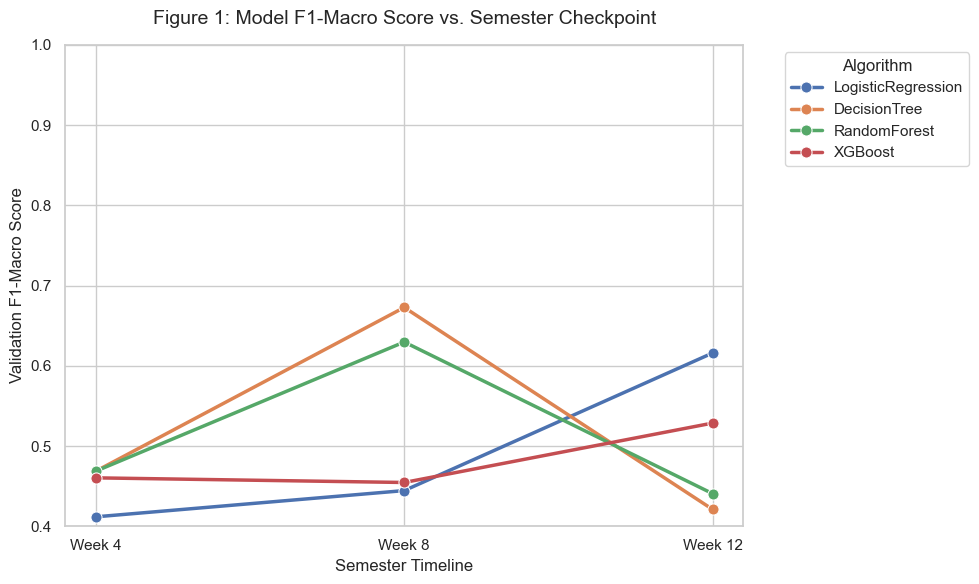

In [ ]:
plt.figure(figsize=(10, 6))

# Create a line plot showing F1 score progression over checkpoints
sns.lineplot(
    data=results_df, 
    x='Checkpoint', 
    y='Val_F1_Macro', 
    hue='Model', 
    marker='o', 
    linewidth=2.5, 
    markersize=8
)

plt.title("Figure 1: Model F1-Macro Score vs. Semester Checkpoint", fontsize=14, pad=15)
plt.ylabel("Validation F1-Macro Score", fontsize=12)
plt.xlabel("Semester Timeline", fontsize=12)
plt.legend(title="Algorithm", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0.4, 1.0)
plt.tight_layout()

# Save deliverable
plot_path = RESULTS_DIR / "figure1_checkpoint_comparison.png"
plt.savefig(plot_path, dpi=300)
print(f"Figure 1 successfully saved to {plot_path}")
plt.show()